# Introduction to Deep Learning

This notebook introduces the fundamental ideas behind Deep Learning.

We will understand:

- What Deep Learning is
- Why Deep Learning became important
- How Deep Learning differs from traditional Machine Learning
- Neural networks as computational models
- Layers, neurons, weights, biases, and activations
- Forward propagation
- Loss functions
- Backpropagation intuition
- Gradient descent
- How a neural network learns
- A neural network implemented from scratch using NumPy

The goal is to build the conceptual and mathematical foundation required
for more advanced Deep Learning topics such as CNNs, RNNs, Transformers,
representation learning, and generative models.

## 1. What Is Deep Learning?

Deep Learning is a subfield of Machine Learning that uses neural networks
with multiple layers to learn increasingly complex representations of data.

A Deep Learning model learns a transformation:

$$
f_\theta : \mathcal{X} \rightarrow \mathcal{Y}
$$

where:

- $x \in \mathcal{X}$ is an input
- $y \in \mathcal{Y}$ is the target
- $\theta$ represents the learnable parameters
- $f_\theta$ is the neural network

The key idea is that useful representations do not necessarily need to be
manually designed. A sufficiently expressive neural network can learn
representations directly from data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("NumPy version:", np.__version__)

NumPy version: 2.5.1


## 2. Why Deep Learning?

Many real-world problems involve data whose useful patterns are difficult
to describe using manually designed rules.

Examples include:

- Images
- Speech
- Natural language
- Video
- Sensor signals
- High-dimensional scientific data

Deep Learning addresses this by learning hierarchical representations.

For an image, for example, different layers may learn representations
corresponding to:

$$
\text{pixels}
\rightarrow
\text{edges}
\rightarrow
\text{textures}
\rightarrow
\text{parts}
\rightarrow
\text{objects}
$$

The exact representations are learned from data rather than explicitly
programmed by the developer.

## 3. Feature Engineering vs Representation Learning

A central characteristic of Deep Learning is representation learning.

In a traditional pipeline, useful features may need to be manually designed.

In Deep Learning, the model learns a sequence of transformations:

$$
x
\rightarrow
h^{(1)}
\rightarrow
h^{(2)}
\rightarrow
\cdots
\rightarrow
h^{(L)}
\rightarrow
\hat{y}
$$

where each $h^{(l)}$ is a learned representation.

This allows the network to construct increasingly abstract representations
as information moves through the layers.

## 4. Biological Inspiration

Artificial neural networks were historically inspired by biological neurons.

A simplified artificial neuron receives inputs, applies a weighted sum,
adds a bias, and then applies an activation function.

$$
z = \sum_{i=1}^{n} w_i x_i + b
$$

or equivalently:

$$
z = \mathbf{w}^{T}\mathbf{x} + b
$$

The activation function produces:

$$
a = \phi(z)
$$

The biological analogy is useful for intuition, but artificial neural
networks should not be treated as accurate models of biological brains.

## 5. The Artificial Neuron

In [2]:
x = np.array([1.0, 2.0, 3.0])
w = np.array([0.5, -0.2, 0.8])
b = 0.4

z = np.dot(w, x) + b

print("Input:", x)
print("Weights:", w)
print("Bias:", b)
print("Weighted sum:", z)

Input: [1. 2. 3.]
Weights: [ 0.5 -0.2  0.8]
Bias: 0.4
Weighted sum: 2.9


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

a = sigmoid(z)

print("Neuron output:", a)

Neuron output: 0.9478464369215823


## 6. Activation Functions

Without nonlinear activation functions, stacking multiple linear layers
would still produce a linear transformation.

Therefore, nonlinear activation functions are fundamental to neural networks.

### Sigmoid

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

### Tanh

$$
\tanh(z)
$$

### ReLU

$$
\operatorname{ReLU}(z) = \max(0,z)
$$

### Leaky ReLU

$$
\operatorname{LeakyReLU}(z)
=
\max(\alpha z,z)
$$

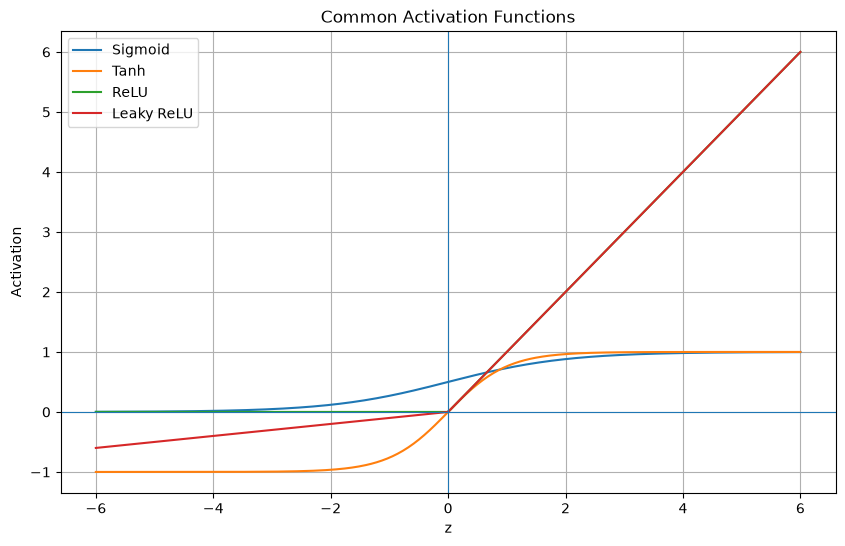

In [4]:
z = np.linspace(-6, 6, 400)

sigmoid_values = 1 / (1 + np.exp(-z))
tanh_values = np.tanh(z)
relu_values = np.maximum(0, z)
leaky_relu_values = np.where(z > 0, z, 0.1 * z)

plt.figure(figsize=(10, 6))

plt.plot(z, sigmoid_values, label="Sigmoid")
plt.plot(z, tanh_values, label="Tanh")
plt.plot(z, relu_values, label="ReLU")
plt.plot(z, leaky_relu_values, label="Leaky ReLU")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("Common Activation Functions")
plt.xlabel("z")
plt.ylabel("Activation")
plt.legend()
plt.grid(True)
plt.show()

## 7. From a Neuron to a Neural Network

A neural network combines many neurons into layers.

A basic feedforward network can be represented as:

$$
\mathbf{x}
\rightarrow
\mathbf{h}^{(1)}
\rightarrow
\mathbf{h}^{(2)}
\rightarrow
\hat{\mathbf{y}}
$$

For layer $l$:

$$
\mathbf{z}^{(l)}
=
\mathbf{W}^{(l)}
\mathbf{a}^{(l-1)}
+
\mathbf{b}^{(l)}
$$

and:

$$
\mathbf{a}^{(l)}
=
\phi^{(l)}
\left(
\mathbf{z}^{(l)}
\right)
$$

with:

$$
\mathbf{a}^{(0)} = \mathbf{x}
$$

This repeated transformation is the basic computational structure of a
feedforward neural network.

## 8. What Makes a Network Deep?

A neural network becomes deep when it contains multiple layers of learned
transformations between the input and output.

For example:

$$
x
\rightarrow
h^{(1)}
\rightarrow
h^{(2)}
\rightarrow
h^{(3)}
\rightarrow
h^{(4)}
\rightarrow
\hat{y}
$$

The depth allows the model to construct hierarchical representations.

Depth and width are different concepts:

- **Depth** → number of layers
- **Width** → number of units in a layer

Increasing either can increase the representational capacity of a model,
although their effects on optimization and generalization are different.

## 9. Forward Propagation

Forward propagation is the process of transforming an input through the
network to produce a prediction.

For a two-layer network:

$$
\mathbf{z}^{(1)}
=
\mathbf{W}^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}
$$

$$
\mathbf{a}^{(1)}
=
\phi(\mathbf{z}^{(1)})
$$

$$
\mathbf{z}^{(2)}
=
\mathbf{W}^{(2)}\mathbf{a}^{(1)}
+
\mathbf{b}^{(2)}
$$

$$
\hat{\mathbf{y}}
=
g(\mathbf{z}^{(2)})
$$

The output $\hat{\mathbf{y}}$ is the prediction produced by the network.

In [5]:
x = np.array([[0.5],
              [1.0]])

W1 = np.array([[0.2, -0.4],
               [0.7, 0.3],
               [-0.5, 0.8]])

b1 = np.array([[0.1],
               [0.2],
               [-0.1]])

W2 = np.array([[0.6, -0.2, 0.5]])
b2 = np.array([[0.1]])

z1 = W1 @ x + b1
a1 = np.maximum(0, z1)

z2 = W2 @ a1 + b2
y_hat = sigmoid(z2)

print("Hidden pre-activation:\n", z1)
print("\nHidden activation:\n", a1)
print("\nOutput:\n", y_hat)

Hidden pre-activation:
 [[-0.2 ]
 [ 0.85]
 [ 0.45]]

Hidden activation:
 [[0.  ]
 [0.85]
 [0.45]]

Output:
 [[0.53867261]]


## 10. Parameters

The parameters of a neural network are the values learned during training.

For a layer:

$$
\mathbf{z}
=
\mathbf{W}\mathbf{x}
+
\mathbf{b}
$$

the learnable parameters are:

- Weight matrix $\mathbf{W}$
- Bias vector $\mathbf{b}$

For a network with $L$ layers:

$$
\theta =
\{
\mathbf{W}^{(1)},\mathbf{b}^{(1)},
\dots,
\mathbf{W}^{(L)},\mathbf{b}^{(L)}
\}
$$

Training attempts to find parameter values that minimize the chosen
objective function.

In [6]:
def count_parameters(weights, biases):
    return sum(w.size for w in weights) + sum(b.size for b in biases)


weights = [W1, W2]
biases = [b1, b2]

print("Total trainable parameters:", count_parameters(weights, biases))

Total trainable parameters: 13


## 11. Loss Function

The network needs a way to measure how different its prediction is from
the target.

This is done using a loss function.

For binary classification, binary cross-entropy is:

$$
\mathcal{L}(y,\hat{y})
=
-
\left[
y\log(\hat{y})
+
(1-y)\log(1-\hat{y})
\right]
$$

For a dataset containing $m$ examples:

$$
J(\theta)
=
\frac{1}{m}
\sum_{i=1}^{m}
\mathcal{L}
\left(
y^{(i)},
\hat{y}^{(i)}
\right)
$$

Training attempts to minimize this objective.

In [7]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)

    return -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )


y_true = np.array([[1]])

loss = binary_cross_entropy(y_true, y_hat)

print("Loss:", loss)

Loss: 0.6186473041129436


## 12. Learning Through Gradients

The network changes its parameters according to the gradient of the loss.

For a parameter $\theta$:

$$
\theta
\leftarrow
\theta
-
\eta
\frac{\partial J}{\partial \theta}
$$

where:

- $\eta$ is the learning rate
- $J$ is the loss
- $\frac{\partial J}{\partial\theta}$ is the gradient

The gradient indicates how the loss changes when a parameter changes.

Gradient descent repeatedly updates the parameters in a direction that
reduces the objective.

## 13. Backpropagation

Backpropagation efficiently computes gradients of the loss with respect to
the network parameters.

It applies the chain rule through the computational graph.

Conceptually:

$$
\text{Loss}
\rightarrow
\text{Output Layer}
\rightarrow
\text{Hidden Layers}
\rightarrow
\text{Input}
$$

The gradients are propagated backward through the network.

Backpropagation itself computes gradients.

The parameter update is performed by an optimization algorithm such as
gradient descent or Adam.

Therefore:

**Backpropagation ≠ Gradient Descent**

Backpropagation computes gradients, while the optimizer uses those
gradients to update parameters.

## 14. Computational Graph

A neural network can be viewed as a computational graph.

For a simple neuron:

$$
x
\rightarrow
wx+b
\rightarrow
\phi(z)
\rightarrow
\hat{y}
\rightarrow
\mathcal{L}
$$

Each operation contributes to the final output.

During backpropagation, derivatives are calculated by applying the chain
rule through this graph.

## 15. Gradient Descent Visualization

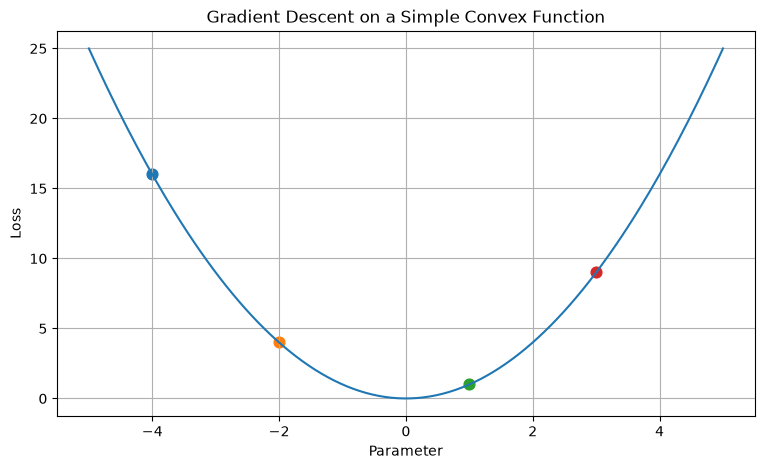

In [8]:
x = np.linspace(-5, 5, 200)
y = x**2

plt.figure(figsize=(9, 5))
plt.plot(x, y)

points = np.array([-4, -2, 1, 3])

for p in points:
    plt.scatter(p, p**2, s=60)

plt.title("Gradient Descent on a Simple Convex Function")
plt.xlabel("Parameter")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

For a simple objective:

$$
J(\theta)=\theta^2
$$

the gradient is:

$$
\frac{dJ}{d\theta}=2\theta
$$

Gradient descent repeatedly moves $\theta$ toward the minimum.

## 16. Neural Network Training Loop

A typical training process follows this cycle:

1. Initialize parameters
2. Perform forward propagation
3. Calculate the loss
4. Perform backpropagation
5. Calculate gradients
6. Update parameters
7. Repeat

Conceptually:

$$
\boxed{
\text{Forward}
\rightarrow
\text{Loss}
\rightarrow
\text{Backward}
\rightarrow
\text{Update}
}
$$

This process is repeated over many training iterations.

## 17. Implement a Tiny Neural Network From Scratch

In [9]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

This is XOR, which is useful because it demonstrates why nonlinear hidden layers matter.

## Model

In [10]:
np.random.seed(42)

input_size = 2
hidden_size = 4
output_size = 1

W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

## Activation functions

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

## Forward pass

In [12]:
def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = np.tanh(z1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    return z1, a1, z2, a2

## Loss

In [13]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)

    return -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

## 18. Backpropagation From Scratch

In [14]:
learning_rate = 1.0
epochs = 10000

loss_history = []

m = X.shape[0]

for epoch in range(epochs):

    # Forward propagation
    z1, a1, z2, y_hat = forward(X, W1, b1, W2, b2)

    # Loss
    loss = binary_cross_entropy(y, y_hat)
    loss_history.append(loss)

    # Output gradients
    dz2 = y_hat - y

    dW2 = (a1.T @ dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Hidden-layer gradients
    da1 = dz2 @ W2.T
    dz1 = da1 * (1 - np.tanh(z1)**2)

    dW1 = (X.T @ dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Parameter updates
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

## 19. Training Loss

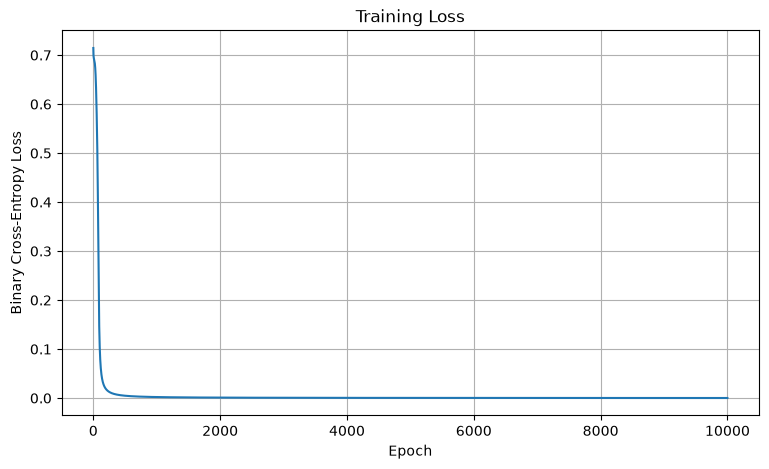

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(loss_history)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.show()

## 20. Predictions

In [16]:
_, _, _, predictions = forward(X, W1, b1, W2, b2)

predicted_classes = (predictions >= 0.5).astype(int)

print("Predicted probabilities:")
print(predictions)

print("\nPredicted classes:")
print(predicted_classes)

print("\nTrue labels:")
print(y.astype(int))

Predicted probabilities:
[[1.54015584e-04]
 [9.99966375e-01]
 [9.99710158e-01]
 [2.40599261e-04]]

Predicted classes:
[[0]
 [1]
 [1]
 [0]]

True labels:
[[0]
 [1]
 [1]
 [0]]


## 21. Why the Hidden Layer Matters

The XOR problem cannot be represented by a single linear decision boundary.

A nonlinear hidden layer allows the network to construct an intermediate
representation that makes the problem solvable.

This illustrates an important Deep Learning principle:

> Neural networks gain expressive power by composing transformations,
> especially nonlinear transformations.

The hidden layers are not merely additional computation. They create
learned intermediate representations.

## 22. Important Terminology

| Term | Meaning |
|---|---|
| Neuron | Computational unit that transforms inputs |
| Weight | Learnable parameter controlling an input's contribution |
| Bias | Learnable offset |
| Activation | Output of a neuron/layer after applying a function |
| Layer | Collection of computational units |
| Hidden Layer | Layer between input and output |
| Forward Propagation | Computing predictions |
| Loss | Quantifies prediction error |
| Gradient | Derivative of the objective with respect to parameters |
| Backpropagation | Efficient gradient computation |
| Optimizer | Uses gradients to update parameters |
| Epoch | One complete pass through the training dataset |
| Batch | Subset of training examples |
| Learning Rate | Controls the magnitude of parameter updates |
| Parameter | Learnable value of the model |
| Hyperparameter | Training/model setting chosen externally |

## 23. Deep Learning Mental Model

The complete picture is:

$$
\text{Data}
\rightarrow
\text{Neural Network}
\rightarrow
\text{Prediction}
\rightarrow
\text{Loss}
\rightarrow
\text{Gradients}
\rightarrow
\text{Parameter Updates}
$$

Repeated many times:

$$
\boxed{
\text{Forward}
\rightarrow
\text{Loss}
\rightarrow
\text{Backpropagation}
\rightarrow
\text{Optimization}
\rightarrow
\text{Repeat}
}
$$

The central idea of Deep Learning is therefore not simply "using neural
networks."

It is learning useful hierarchical representations through compositions
of parameterized nonlinear transformations.

01_Introduction_to_Deep_Learning.ipynb
│
├── 0. Notebook Overview
├── 1. What Is Deep Learning?
├── 2. Why Deep Learning?
├── 3. Feature Engineering vs Representation Learning
├── 4. Biological Inspiration
├── 5. The Artificial Neuron
├── 6. Activation Functions
├── 7. From Neuron to Neural Network
├── 8. What Makes a Network Deep?
├── 9. Forward Propagation
├── 10. Parameters
├── 11. Loss Function
├── 12. Learning Through Gradients
├── 13. Backpropagation
├── 14. Computational Graph
├── 15. Gradient Descent Visualization
├── 16. Neural Network Training Loop
├── 17. Tiny Neural Network From Scratch
├── 18. Backpropagation From Scratch
├── 19. Training Loss Visualization
├── 20. Predictions
├── 21. Why the Hidden Layer Matters
├── 22. Important Deep Learning Terminology
├── 23. Deep Learning Mental Model
└── 24. Learning Checklist